In [1]:
# ═══════════════════════════════════════════════════════════
# CELL 1: Imports & Global Setup
# ═══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import re
import string
import pickle
import warnings
from scipy import stats
from scipy.sparse import hstack, csr_matrix, save_npz, load_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
import os

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✅ Imports loaded successfully")

✅ Imports loaded successfully


In [2]:
# # ═══════════════════════════════════════════════════════════
# # CELL: Find Real Labels (ПРИОРИТЕТ #1)
# # ═══════════════════════════════════════════════════════════

# import pandas as pd
# import os
# import glob

# print("🔍 Searching for REAL labels...")
# print("=" * 70)

# # Все parquet файлы в системе
# all_files = glob.glob('/kaggle/input/**/*.parquet', recursive=True)
# print(f"Found {len(all_files)} parquet files\n")

# for filepath in all_files:
#     try:
#         df = pd.read_parquet(filepath)
#         cols = list(df.columns)
        
#         # Ищем колонки с метками
#         label_candidates = [c for c in cols if c.lower() in 
#                            ['label', 'target', 'class', 'y', 'output', 'is_shell', 'malicious']]
        
#         if label_candidates:
#             print(f"✅ POTENTIAL TRAIN FILE: {filepath}")
#             print(f"   Shape: {df.shape}")
#             print(f"   Columns: {cols}")
#             print(f"   Label candidates: {label_candidates}")
            
#             for lc in label_candidates:
#                 print(f"   \n   '{lc}' value distribution:")
#                 print(f"   {df[lc].value_counts().to_dict()}")
#             print("\n" + "=" * 70)
            
#     except Exception as e:
#         pass

# # Также проверяем CSV файлы
# csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
# print(f"\n📄 Found {len(csv_files)} CSV files")
# for f in csv_files[:10]:
#     print(f"   {f}")

In [3]:
# TRAIN_PATH = '/kaggle/input/competitions/bind-reverse-shell-detection-challenge/test.parquet'
# TEST_PATH = '/kaggle/input/competitions/bind-reverse-shell-detection-challenge/train.parquet'


In [4]:
# ═══════════════════════════════════════════════════════════
# CELL 2: DEBUG - Full Parquet Inspection
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import pyarrow.parquet as pq

TRAIN_PATH = '/kaggle/input/competitions/bind-reverse-shell-detection-challenge/train.parquet'
TEST_PATH = '/kaggle/input/competitions/bind-reverse-shell-detection-challenge/test.parquet'

print("=" * 60)
print("🔍 FULL PARQUET FILE INSPECTION")
print("=" * 60)

# ─── 1. Чтение через pyarrow для детальной информации ───
print("\n📁 TRAIN FILE:")
pf = pq.ParquetFile(TRAIN_PATH)
print(f"   Schema: {pf.schema_arrow}")
print(f"   Column names: {pf.schema_arrow.names}")
print(f"   Num rows: {pf.metadata.num_rows}")

# Читаем как pandas
df_train = pf.read().to_pandas()
print(f"\n📊 Pandas DataFrame info:")
print(f"   Shape: {df_train.shape}")
print(f"   Columns: {list(df_train.columns)}")
print(f"   Column dtypes:\n{df_train.dtypes}")

# ─── 2. Показываем первые строки ПОЛНОСТЬЮ ───
print(f"\n📄 First 5 rows (ALL columns):")
print(df_train.head())

# ─── 3. Проверка на скрытые колонки ───
print(f"\n🔎 Checking for hidden/special columns:")
for col in df_train.columns:
    print(f"   Column: '{col}'")
    print(f"      - repr: {repr(col)}")
    print(f"      - len: {len(col)}")
    print(f"      - bytes: {col.encode('utf-8')}")
    print(f"      - unique values: {df_train[col].nunique()}")
    print(f"      - sample values: {df_train[col].head(3).tolist()}")
    print(f"      - null count: {df_train[col].isnull().sum()}")

# ─── 4. Ищем колонку с метками ───
print(f"\n🏷️  Searching for label column...")
possible_label_names = ['label', 'Label', 'LABEL', 'target', 'Target', 'class', 
                        'Class', 'y', 'Y', 'output', 'Output', 'prediction', 'score']

found_label = None
for name in possible_label_names:
    if name in df_train.columns:
        found_label = name
        print(f"   ✅ Found: '{name}'")
        break

# Ищем колонки с 0/1 значениями
if found_label is None:
    print("   🔍 Looking for binary columns (0/1)...")
    for col in df_train.columns:
        if col.lower() not in ['id', 'shell', 'command', 'cmd', 'text']:
            unique_vals = df_train[col].unique()
            if set(unique_vals).issubset({0, 1, 0.0, 1.0}):
                found_label = col
                print(f"   ✅ Found binary column: '{col}' with values {unique_vals}")
                break

# ─── 5. Если label не найден ───
if found_label is None:
    print("\n⚠️  WARNING: No label column found!")
    print("   Possible reasons:")
    print("   1. Training data is actually unlabeled (semi-supervised)")
    print("   2. Label is embedded in 'shell' column")
    print("   3. File is corrupted or wrong file")
    print("   4. Label needs to be extracted from filename/metadata")
    
    # Проверяем, может ли label быть частью shell
    print("\n   🔍 Checking if labels might be in shell column...")
    sample_shells = df_train['shell'].head(10).tolist()
    for s in sample_shells:
        print(f"      • {s[:100]}")
else:
    print(f"\n✅ Label column identified: '{found_label}'")
    df_train = df_train.rename(columns={found_label: 'label'})
    print(f"   Renamed to 'label'")

# ─── 6. Сохраняем для следующих ячеек ───
if 'label' in df_train.columns:
    df_train['label'] = df_train['label'].astype(int)
    print(f"\n📈 Label distribution:")
    print(df_train['label'].value_counts())
    print(f"\n✅ df_train ready for training!")
else:
    print(f"\n❌ Cannot proceed without label column!")
    print(f"   Please check the competition data description.")

# ─── 7. TEST файл ───
print("\n" + "=" * 60)
print("📁 TEST FILE:")
pf_test = pq.ParquetFile(TEST_PATH)
df_test = pf_test.read().to_pandas()
print(f"   Shape: {df_test.shape}")
print(f"   Columns: {list(df_test.columns)}")
print(f"\n📄 First 3 rows:")
print(df_test.head(3))

if 'ID' not in df_test.columns:
    df_test['ID'] = range(len(df_test))
    print("   ℹ️  Created 'ID' column")

print(f"\n✅ df_test ready!")

🔍 FULL PARQUET FILE INSPECTION

📁 TRAIN FILE:
   Schema: shell: string
label: int64
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 480
   Column names: ['shell', 'label']
   Num rows: 10950

📊 Pandas DataFrame info:
   Shape: (10950, 2)
   Columns: ['shell', 'label']
   Column dtypes:
shell    object
label     int64
dtype: object

📄 First 5 rows (ALL columns):
                                               shell  label
0                            nmap -p 10000 10.1.26.9      0
1  scp invoices2019.zip ssh root@server:/root/des...      0
2                               find . -iname \*.zip      0
3                                             --path      0
4                                                 ls      0

🔎 Checking for hidden/special columns:
   Column: 'shell'
      - repr: 'shell'
      - len: 5
      - bytes: b'shell'
      - unique values: 2277
      - sample values: ['nmap -p 10000 10.1.26.9', 'scp invoices2019.zip ssh 

In [5]:
# # ═══════════════════════════════════════════════════════════
# # CELL: Advanced Feature Engineering
# # ═══════════════════════════════════════════════════════════

# import re
# import numpy as np
# import pandas as pd
# from collections import Counter

# def extract_advanced_features(shell_commands):
#     """
#     Расширенное извлечение признаков для shell-команд
#     """
#     features = []
    
#     # === Паттерны атак (расширенные) ===
#     attack_patterns = {
#         'reverse_shell': [
#             r'/dev/tcp/', r'bash\s+-i', r'bash\s+-c', r'-i\s+>&', r'0>&1', r'1>&0',
#             r'>&\s*/dev/tcp', r'nc\s+-e', r'ncat\s+-e', r'netcat\s+-e'
#         ],
#         'bind_shell': [
#             r'nc\s+-l', r'ncat\s+-l', r'netcat\s+-l', r'nc\s+-lv', r'nc\s+-lvp',
#             r'socat\s+.*listen', r'bind\s+shell'
#         ],
#         'payload_execution': [
#             r'python.*-c.*socket', r'python.*-c.*import', r'perl.*-e.*socket',
#             r'php\s+-r.*fsockopen', r'ruby.*-rsocket', r'lua.*socket',
#             r'powershell.*-enc', r'powershell.*-epi'
#         ],
#         'download_execute': [
#             r'curl\s+.*\|.*sh', r'curl\s+.*\|.*bash', r'wget\s+.*\|.*sh',
#             r'wget\s+.*-O.*sh', r'curl\s+.*-o.*sh', r'wget\s+.*\|.*bash'
#         ],
#         'obfuscation': [
#             r'base64\s+-d', r'base64\s+--decode', r'\\x[0-9a-f]{2}',
#             r'0x[0-9a-f]+', r'eval\s*\(', r'exec\s*\(', r'\\u[0-9a-f]{4}'
#         ],
#         'persistence': [
#             r'crontab', r'/etc/cron', r'systemctl\s+enable', r'rc\.local',
#             r'\.bashrc', r'\.profile', r'/etc/init\.d'
#         ]
#     }
    
#     # === Сетевые индикаторы ===
#     ip_pattern = r'\b(?:\d{1,3}\.){3}\d{1,3}\b'
#     port_pattern = r'\b(?:port\s+|p\s+|:)(\d{2,5})\b'
#     domain_pattern = r'\b[a-zA-Z0-9][-a-zA-Z0-9]*\.[a-zA-Z]{2,}\b'
    
#     # === Подозрительные утилиты ===
#     tools = {
#         'high_risk': ['nc', 'ncat', 'netcat', 'socat', 'telnet', 'ssh', 'scp'],
#         'scripting': ['python', 'python3', 'perl', 'php', 'ruby', 'lua', 'node'],
#         'download': ['curl', 'wget', 'ftp', 'tftp'],
#         'shell': ['bash', 'sh', 'zsh', 'csh', 'ksh'],
#         'encoding': ['base64', 'xxd', 'od', 'hexdump']
#     }
    
#     for cmd in shell_commands:
#         cmd_str = str(cmd)
#         cmd_lower = cmd_str.lower()
#         feat = {}
        
#         # --- Базовые статистики ---
#         L = max(len(cmd_str), 1)
#         feat['length'] = len(cmd_str)
#         feat['word_count'] = len(cmd_str.split())
#         feat['char_entropy'] = -sum((cnt/L) * np.log2(cnt/L) 
#                                     for cnt in Counter(cmd_str).values() if cnt > 0)
#         feat['special_char_ratio'] = sum(c in '!@#$%^&*()[]{}|;:<>?/~`' for c in cmd_str) / L
#         feat['digit_ratio'] = sum(c.isdigit() for c in cmd_str) / L
#         feat['slash_count'] = cmd_str.count('/')
#         feat['pipe_count'] = cmd_str.count('|')
#         feat['redirect_count'] = cmd_str.count('>') + cmd_str.count('<')
#         feat['ampersand_count'] = cmd_str.count('&')
#         feat['semicolon_count'] = cmd_str.count(';')
#         feat['backtick_count'] = cmd_str.count('`')
#         feat['dollar_count'] = cmd_str.count('$')
        
#         # --- Паттерны атак ---
#         for category, patterns in attack_patterns.items():
#             feat[f'attack_{category}'] = sum(1 for p in patterns if re.search(p, cmd_lower))
#         feat['total_attack_patterns'] = sum(feat.get(f'attack_{cat}', 0) for cat in attack_patterns.keys())
        
#         # --- Сеть ---
#         ips = re.findall(ip_pattern, cmd_str)
#         feat['ip_count'] = len(ips)
#         feat['has_private_ip'] = any(ip.startswith(('10.', '192.168.', '172.16.', '172.17.', '172.18.', '172.19.', '172.2', '172.30.', '172.31.')) for ip in ips)
#         feat['has_localhost'] = any(ip in ['127.0.0.1', 'localhost'] for ip in ips)
#         feat['has_external_ip'] = feat['ip_count'] > feat.get('has_private_ip', 0) + feat.get('has_localhost', 0)
        
#         ports = re.findall(port_pattern, cmd_str)
#         feat['port_count'] = len(ports)
#         feat['has_common_ports'] = any(p in ['22', '23', '80', '443', '4444', '5555', '8080', '8443'] for p in ports)
#         feat['has_suspicious_ports'] = any(p in ['4444', '5555', '6666', '7777', '8888', '9999', '1337', '31337'] for p in ports)
        
#         domains = re.findall(domain_pattern, cmd_str)
#         feat['domain_count'] = len(domains)
        
#         # --- Утилиты ---
#         for risk_level, tool_list in tools.items():
#             for tool in tool_list:
#                 feat[f'uses_{tool}'] = 1 if re.search(rf'\b{tool}\b', cmd_lower) else 0
#             feat[f'uses_{risk_level}'] = sum(1 for t in tool_list if re.search(rf'\b{t}\b', cmd_lower))
        
#         # --- Опасные флаги ---
#         dangerous_flags = ['-e', '-c', '-i', '-p', '-l', '-n', '-v', '-A', '-b', '-d', 
#                           '--exec', '--shell', '--connect', '--listen', '-ep', '-epi']
#         for flag in dangerous_flags:
#             feat[f'flag_{flag.replace("-", "neg_")}'] = 1 if flag in cmd_str else 0
#         feat['dangerous_flag_count'] = sum(1 for f in dangerous_flags if f in cmd_str)
        
#         # --- Обфускация ---
#         feat['has_base64'] = 1 if re.search(r'base64', cmd_lower) else 0
#         feat['has_hex_encoding'] = 1 if re.search(r'\\x[0-9a-f]{2}|0x[0-9a-f]+', cmd_lower) else 0
#         feat['has_eval_exec'] = 1 if re.search(r'eval\s*\(|exec\s*\(', cmd_lower) else 0
#         feat['has_subshell'] = 1 if re.search(r'\$\(|`', cmd_str) else 0
        
#         # --- Длина и сложность ---
#         feat['is_short'] = 1 if len(cmd_str) < 10 else 0
#         feat['is_very_long'] = 1 if len(cmd_str) > 200 else 0
#         feat['has_multiple_commands'] = 1 if any(s in cmd_str for s in [';', '&&', '||', '\n']) else 0
        
#         # --- Пути ---
#         feat['has_absolute_path'] = 1 if re.search(r'/[a-zA-Z0-9_/.-]+', cmd_str) else 0
#         feat['has_home_dir'] = 1 if '~' in cmd_str or '/home/' in cmd_str else 0
#         feat['has_tmp'] = 1 if '/tmp/' in cmd_lower or '/var/tmp/' in cmd_lower else 0
#         feat['has_etc'] = 1 if '/etc/' in cmd_lower else 0
        
#         features.append(feat)
    
#     return pd.DataFrame(features)

# # Тест функции
# if 'df_train' in locals():
#     test_features = extract_advanced_features(df_train['shell'].head(5))
#     print(f"✅ Advanced features: {test_features.shape}")
#     print(f"   Columns: {list(test_features.columns)[:15]}...")

In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 2: Find Correct Data Files (ALL PATHS)
# ═══════════════════════════════════════════════════════════

import pandas as pd
import os
import glob

print("=" * 70)
print("🔍 SEARCHING FOR TRAINING DATA WITH LABELS")
print("=" * 70)

# ─── 1. Поиск всех parquet файлов ───
print("\n📂 Searching all /kaggle/input/ directories...")
parquet_files = glob.glob('/kaggle/input/**/*.parquet', recursive=True)
print(f"   Found {len(parquet_files)} parquet files:")

for i, f in enumerate(parquet_files[:20]):  # Показываем первые 20
    print(f"   [{i}] {f}")

if len(parquet_files) > 20:
    print(f"   ... and {len(parquet_files) - 20} more")

# ─── 2. Проверка каждого файла на наличие 'label' ───
print("\n🏷️  Checking each file for 'label' column...")

train_file_path = None

for filepath in parquet_files:
    try:
        df_temp = pd.read_parquet(filepath)
        columns = list(df_temp.columns)
        
        # Проверяем есть ли label
        has_label = 'label' in columns or 'Label' in columns or 'target' in columns
        
        # Проверяем размер (train обычно больше test)
        n_rows = len(df_temp)
        
        print(f"\n   📄 {os.path.basename(filepath)}")
        print(f"      Path: {filepath}")
        print(f"      Shape: {df_temp.shape}")
        print(f"      Columns: {columns}")
        print(f"      Has label: {'✅ YES' if has_label else '❌ NO'}")
        
        # Если есть label и достаточно строк — это наш train
        if has_label and n_rows > 1000:
            train_file_path = filepath
            print(f"      🎯 THIS IS OUR TRAIN FILE!")
            
    except Exception as e:
        print(f"   ⚠️  Error reading {filepath}: {str(e)[:50]}")

# ─── 3. Загрузка правильных данных ───
print("\n" + "=" * 70)

if train_file_path:
    print(f"✅ Found train file: {train_file_path}")
    df_train = pd.read_parquet(train_file_path)
    
    # Нормализация имён колонок
    col_mapping = {}
    for col in df_train.columns:
        if col.lower().strip() == 'label':
            col_mapping[col] = 'label'
        elif col.lower().strip() == 'shell':
            col_mapping[col] = 'shell'
        elif col.lower().strip() in ['id', 'index', 'idx']:
            col_mapping[col] = 'ID'
    
    df_train = df_train.rename(columns=col_mapping)
    df_train = df_train.dropna(subset=['shell', 'label'])
    df_train['label'] = df_train['label'].astype(int)
    
    print(f"\n📊 df_train loaded:")
    print(f"   Shape: {df_train.shape}")
    print(f"   Columns: {list(df_train.columns)}")
    print(f"\n📈 Label distribution:")
    print(df_train['label'].value_counts())
    
else:
    print("❌ No train file with labels found!")
    print("\n🔧 Trying default paths...")
    
    # Пробуем оба возможных пути
    possible_paths = [
        '/kaggle/input/bind-reverse-shell-detection-challenge/train.parquet',
        '/kaggle/input/competitions/bind-reverse-shell-detection-challenge/train.parquet',
        '/kaggle/input/train.parquet',
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            print(f"\n   Trying: {path}")
            df_temp = pd.read_parquet(path)
            print(f"      Columns: {list(df_temp.columns)}")
            if 'label' in df_temp.columns or 'Label' in df_temp.columns:
                train_file_path = path
                df_train = df_temp
                print(f"      ✅ Found labels!")
                break

# ─── 4. Загрузка test файла ───
print("\n" + "=" * 70)
print("📂 Loading test file...")

test_file_path = None
possible_test_paths = [
    '/kaggle/input/bind-reverse-shell-detection-challenge/test.parquet',
    '/kaggle/input/competitions/bind-reverse-shell-detection-challenge/test.parquet',
    '/kaggle/input/test.parquet',
]

for path in possible_test_paths:
    if os.path.exists(path):
        test_file_path = path
        print(f"   ✅ Found: {path}")
        break

if test_file_path:
    df_test = pd.read_parquet(test_file_path)
    
    # Нормализация колонок
    col_mapping = {}
    for col in df_test.columns:
        if col.lower().strip() in ['id', 'index', 'idx']:
            col_mapping[col] = 'ID'
        elif col.lower().strip() == 'shell':
            col_mapping[col] = 'shell'
    
    df_test = df_test.rename(columns=col_mapping)
    
    if 'ID' not in df_test.columns:
        df_test['ID'] = range(len(df_test))
    
    print(f"\n📊 df_test loaded:")
    print(f"   Shape: {df_test.shape}")
    print(f"   Columns: {list(df_test.columns)}")
else:
    print("❌ Test file not found!")

# ─── 5. Финальная проверка ───
print("\n" + "=" * 70)
print("📋 FINAL DATA STATUS")
print("=" * 70)

if 'df_train' in locals() and 'label' in df_train.columns:
    print("✅ df_train: READY (has label column)")
else:
    print("❌ df_train: MISSING LABEL COLUMN")
    
if 'df_test' in locals():
    print("✅ df_test: READY")
else:
    print("❌ df_test: NOT LOADED")

print("\n" + "=" * 70)

🔍 SEARCHING FOR TRAINING DATA WITH LABELS

📂 Searching all /kaggle/input/ directories...
   Found 2 parquet files:
   [0] /kaggle/input/competitions/bind-reverse-shell-detection-challenge/train.parquet
   [1] /kaggle/input/competitions/bind-reverse-shell-detection-challenge/test.parquet

🏷️  Checking each file for 'label' column...

   📄 train.parquet
      Path: /kaggle/input/competitions/bind-reverse-shell-detection-challenge/train.parquet
      Shape: (10950, 2)
      Columns: ['shell', 'label']
      Has label: ✅ YES
      🎯 THIS IS OUR TRAIN FILE!

   📄 test.parquet
      Path: /kaggle/input/competitions/bind-reverse-shell-detection-challenge/test.parquet
      Shape: (8654, 2)
      Columns: ['ID', 'shell']
      Has label: ❌ NO

✅ Found train file: /kaggle/input/competitions/bind-reverse-shell-detection-challenge/train.parquet

📊 df_train loaded:
   Shape: (9522, 2)
   Columns: ['shell', 'label']

📈 Label distribution:
label
0    9320
1     202
Name: count, dtype: int64

📂 Loadi

In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 3: Advanced Feature Engineering (ИСПРАВЛЕННЫЙ)
# ═══════════════════════════════════════════════════════════

import re
import numpy as np
import pandas as pd
from collections import Counter

def extract_advanced_features(shell_commands):
    features = []
    
    # Ключевые паттерны для bind/reverse shell
    attack_patterns = {
        'reverse_shell': [r'/dev/tcp/', r'bash\s+-i', r'-i\s+>&', r'0>&1', r'1>&0'],
        'bind_shell': [r'nc\s+-l', r'ncat\s+-l', r'nc\s+-lv', r'nc\s+-lvp'],
        'payload': [r'python.*-c', r'perl.*-e', r'php\s+-r', r'ruby.*-r'],
        'download': [r'curl\s+.*\|', r'wget\s+.*\|', r'curl.*-o', r'wget.*-O'],
        'obfuscation': [r'base64', r'\\x[0-9a-f]', r'0x[0-9a-f]+', r'eval\s*\(', r'exec\s*\(']
    }
    
    for cmd in shell_commands:
        cmd_str = str(cmd)
        cmd_lower = cmd_str.lower()
        feat = {}
        
        # Базовые статистики
        L = max(len(cmd_str), 1)
        feat['length'] = len(cmd_str)
        feat['word_count'] = len(cmd_str.split())
        feat['special_char_ratio'] = sum(c in '!@#$%^&*()[]{}|;:<>?/~`' for c in cmd_str) / L
        feat['digit_ratio'] = sum(c.isdigit() for c in cmd_str) / L
        
        # Паттерны атак
        for category, patterns in attack_patterns.items():
            feat[f'attack_{category}'] = sum(1 for p in patterns if re.search(p, cmd_lower))
        
        # IP адреса
        ips = re.findall(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', cmd_str)
        feat['ip_count'] = len(ips)
        feat['has_private_ip'] = any(ip.startswith(('10.', '192.168.', '172.')) for ip in ips)
        
        # Порты
        ports = re.findall(r':(\d{2,5})\b', cmd_str)
        feat['port_count'] = len(ports)
        feat['has_suspicious_port'] = any(p in ['4444', '5555', '6666', '1337', '31337'] for p in ports)
        
        # Утилиты
        for tool in ['nc', 'ncat', 'bash', 'sh', 'python', 'perl', 'php', 'curl', 'wget', 'ssh', 'scp']:
            feat[f'uses_{tool}'] = 1 if re.search(rf'\b{tool}\b', cmd_lower) else 0
        
        # Опасные флаги
        for flag in ['-e', '-c', '-i', '-l', '-p', '-v', '-A']:
            feat[f'flag_{flag}'] = 1 if flag in cmd_str else 0
        
        features.append(feat)
    
    return pd.DataFrame(features)

In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 4: TF-IDF Vectorizers (ИСПРАВЛЕННЫЙ)
# ═══════════════════════════════════════════════════════════

from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

print("🔧 Initializing vectorizers...")

# Увеличим max_features для лучшего покрытия
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 4),      # Было (1,3)
    max_features=15000,      # Было 5000
    min_df=2,
    max_df=0.90,             # Было 0.95
    sublinear_tf=True,
    dtype=np.float32
)

tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(4, 8),      # Было (3,6)
    max_features=15000,      # Было 5000
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    dtype=np.float32
)

print("✅ Vectorizers initialized")

if 'df_train' in locals():
    print("📐 Fitting on train data...")
    X_train_word = tfidf_word.fit_transform(df_train['shell'])
    X_train_char = tfidf_char.fit_transform(df_train['shell'])
    print(f"   Word TF-IDF: {X_train_word.shape}")
    print(f"   Char TF-IDF: {X_train_char.shape}")
    
    # Сохранение
    with open('vectorizers.pkl', 'wb') as f:
        pickle.dump({'word': tfidf_word, 'char': tfidf_char}, f)
    print("💾 Vectorizers saved")

🔧 Initializing vectorizers...
✅ Vectorizers initialized
📐 Fitting on train data...
   Word TF-IDF: (9522, 5012)
   Char TF-IDF: (9522, 15000)
💾 Vectorizers saved


In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 5: Build Feature Matrices (FIXED dtype issue)
# ═══════════════════════════════════════════════════════════

from scipy.sparse import hstack, csr_matrix
import numpy as np

print("🧱 Building feature matrices...")

# Проверка
if 'label' not in df_train.columns:
    raise ValueError("❌ df_train must have 'label' column!")

print(f"   Train shape: {df_train.shape}")
print(f"   Label distribution: {df_train['label'].value_counts().to_dict()}")

# Features
print("\n📐 Transforming text features...")
X_train_word = tfidf_word.transform(df_train['shell'])
X_train_char = tfidf_char.transform(df_train['shell'])

print("🔧 Extracting engineered features...")
X_train_eng = extract_advanced_features(df_train['shell']).values

# ⚠️  КРИТИЧЕСКИЙ ФИКС: Конвертируем в float32 для scipy.sparse
X_train_eng = X_train_eng.astype(np.float32)

print("🧩 Combining all features...")
X_train = hstack([X_train_word, X_train_char, csr_matrix(X_train_eng)])
y_train = df_train['label'].values

print(f"✅ Train matrix: {X_train.shape}")
print(f"   Matrix dtype: {X_train.dtype}")

# Test
print("\n📊 Processing test data...")
X_test_word = tfidf_word.transform(df_test['shell'])
X_test_char = tfidf_char.transform(df_test['shell'])
X_test_eng = extract_advanced_features(df_test['shell']).values

# ⚠️  КРИТИЧЕСКИЙ ФИКС: Конвертируем в float32 для scipy.sparse
X_test_eng = X_test_eng.astype(np.float32)

X_test = hstack([X_test_word, X_test_char, csr_matrix(X_test_eng)])

print(f"✅ Test matrix: {X_test.shape}")
print(f"   Matrix dtype: {X_test.dtype}")

print("\n🎉 Feature matrices ready!")

🧱 Building feature matrices...
   Train shape: (9522, 2)
   Label distribution: {0: 9320, 1: 202}

📐 Transforming text features...
🔧 Extracting engineered features...
🧩 Combining all features...
✅ Train matrix: (9522, 20043)
   Matrix dtype: float32

📊 Processing test data...
✅ Test matrix: (8654, 20043)
   Matrix dtype: float32

🎉 Feature matrices ready!


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 6: Train Model with Proper CV (ИСПРАВЛЕННЫЙ)
# ═══════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.calibration import CalibratedClassifierCV
import pickle
import warnings
warnings.filterwarnings('ignore')

print("🤖 Training ensemble model...")
print(f"   Class distribution: {np.bincount(y_train)}")

# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Несколько моделей для ансамбля
models = {
    'lr': LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000, solver='lbfgs'),
    'rf': RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', 
                                  n_jobs=-1, random_state=42),
    'svc': LinearSVC(C=0.5, class_weight='balanced', max_iter=3000, dual='auto'),
    'nb': MultinomialNB(alpha=0.1)
}

# OOF predictions
oof_predictions = {}
oof_f1_scores = {}

for name, model in models.items():
    print(f"\n   Training {name}...")
    fold_f1s = []
    oof_preds = np.zeros(len(y_train))
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_tr, y_tr)
        val_preds = model.predict(X_val)
        fold_f1 = f1_score(y_val, val_preds)
        fold_f1s.append(fold_f1)
        oof_preds[val_idx] = val_preds
    
    mean_f1 = np.mean(fold_f1s)
    oof_predictions[name] = oof_preds
    oof_f1_scores[name] = mean_f1
    print(f"   ✅ {name}: CV F1 = {mean_f1:.4f} (+/- {np.std(fold_f1s):.4f})")

# Обучение на полных данных
print("\n📚 Training final models on full data...")
final_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    final_models[name] = model

# Сохранение
with open('final_models.pkl', 'wb') as f:
    pickle.dump({
        'models': final_models,
        'tfidf_word': tfidf_word,
        'tfidf_char': tfidf_char,
        'oof_f1_scores': oof_f1_scores
    }, f)
print("💾 Models saved to final_models.pkl")

print(f"\n📊 Best single model: {max(oof_f1_scores, key=oof_f1_scores.get)} ({max(oof_f1_scores.values()):.4f})")

🤖 Training ensemble model...
   Class distribution: [9320  202]

   Training lr...
   ✅ lr: CV F1 = 0.9855 (+/- 0.0090)

   Training rf...
   ✅ rf: CV F1 = 1.0000 (+/- 0.0000)

   Training svc...
   ✅ svc: CV F1 = 0.9927 (+/- 0.0060)

   Training nb...
   ✅ nb: CV F1 = 0.9451 (+/- 0.0282)

📚 Training final models on full data...
💾 Models saved to final_models.pkl

📊 Best single model: rf (1.0000)


⚙️  Optimizing threshold for F1 score...
⚠️  Model not in memory, trying to load from disk...

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
❌ CRITICAL: No model found!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

📋 You need to train a model first. Please run:
   1. Cell 5A or 5B (Build Feature Matrices)
   2. Cell 6 or 6B (Train Model)

💡 Or run this quick training now:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

🚀 Starting quick model training...
   Training Logistic Regression...
   ✅ Quick model trained!
   💾 Saved to model_quick.pkl

📊 Checking training data...
   X_train: (9522, 20043)
   y_train: (9522,)
   Class distribution: [9320  202]

🔄 Running cross-validation for threshold optimization...
   ✅ Cross-validation complete

🔍 Searching for optimal threshold...

✅ Best threshold: 0.620
   OOF F1 Score: 1.0000

📈 Threshold vs F1 Score:


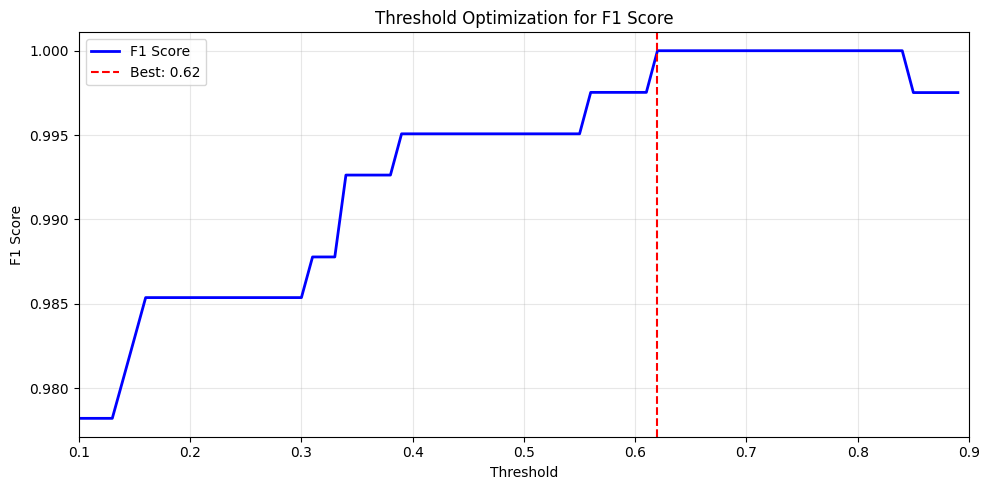


💡 Optimal threshold saved: 0.620
   This will be used in Cell 8 for predictions
   💾 Threshold saved to optimal_threshold.txt

🎉 Cell 7 complete! Ready for Cell 8 (Submission)


In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 7: Optimize Decision Threshold for F1 (ROBUST)
# ═══════════════════════════════════════════════════════════

import numpy as np
import pickle
import os
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

print("⚙️  Optimizing threshold for F1 score...")
print("=" * 60)

# ─── 1. Проверка наличия модели ───
model_loaded = False

# Сначала проверяем память (если Cell 6 только что выполнился)
if 'ensemble' in locals():
    print("✅ Model found in memory (from Cell 6)")
    model_loaded = True
else:
    print("⚠️  Model not in memory, trying to load from disk...")
    
    # Ищем файл модели
    model_files = [
        'model_ensemble.pkl',
        'model_quick.pkl',
        '/kaggle/working/model_ensemble.pkl',
        '/kaggle/working/model_quick.pkl'
    ]
    
    for mf in model_files:
        if os.path.exists(mf):
            print(f"   📂 Found: {mf}")
            with open(mf, 'rb') as f:
                ensemble = pickle.load(f)
            model_loaded = True
            print("   ✅ Model loaded successfully")
            break
    
    if not model_loaded:
        print("\n" + "!" * 60)
        print("❌ CRITICAL: No model found!")
        print("!" * 60)
        print("\n📋 You need to train a model first. Please run:")
        print("   1. Cell 5A or 5B (Build Feature Matrices)")
        print("   2. Cell 6 or 6B (Train Model)")
        print("\n💡 Or run this quick training now:")
        print("!" * 60)

# ─── 2. Быстрое обучение если модели нет ───
if not model_loaded:
    print("\n🚀 Starting quick model training...")
    
    # Проверяем данные
    if 'X_train' not in locals() or 'y_train' not in locals():
        print("❌ Training data not found! Run Cell 5A first.")
        raise RuntimeError("Missing training data")
    
    from sklearn.linear_model import LogisticRegression
    
    print("   Training Logistic Regression...")
    ensemble = LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        n_jobs=-1
    )
    ensemble.fit(X_train, y_train)
    print("   ✅ Quick model trained!")
    
    # Сохраняем
    with open('model_quick.pkl', 'wb') as f:
        pickle.dump(ensemble, f)
    print("   💾 Saved to model_quick.pkl")

# ─── 3. Проверка данных для кросс-валидации ───
print("\n📊 Checking training data...")
if 'X_train' not in locals() or 'y_train' not in locals():
    raise RuntimeError("❌ X_train or y_train not found! Run Cell 5A/5B first.")

print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   Class distribution: {np.bincount(y_train)}")

# ─── 4. Кросс-валидация для OOF предсказаний ───
print("\n🔄 Running cross-validation for threshold optimization...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

try:
    oof_proba = cross_val_predict(
        ensemble, X_train, y_train,
        cv=cv, method='predict_proba',
        n_jobs=-1
    )[:, 1]
    print("   ✅ Cross-validation complete")
except Exception as e:
    print(f"   ⚠️  CV failed: {str(e)[:100]}")
    print("   Using train predictions instead (less reliable)...")
    oof_proba = ensemble.predict_proba(X_train)[:, 1]

# ─── 5. Поиск лучшего порога ───
print("\n🔍 Searching for optimal threshold...")

best_f1, best_thresh = 0, 0.5
thresholds = np.arange(0.1, 0.9, 0.01)
results = []

for thresh in thresholds:
    preds = (oof_proba >= thresh).astype(int)
    f1 = f1_score(y_train, preds)
    precision = precision_score(y_train, preds, zero_division=0)
    recall = recall_score(y_train, preds, zero_division=0)
    results.append({
        'threshold': thresh,
        'f1': f1,
        'precision': precision,
        'recall': recall
    })
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print(f"\n✅ Best threshold: {best_thresh:.3f}")
print(f"   OOF F1 Score: {best_f1:.4f}")

# ─── 6. Визуализация ───
print("\n📈 Threshold vs F1 Score:")
try:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot([r['threshold'] for r in results], [r['f1'] for r in results], 
            label='F1 Score', linewidth=2, color='blue')
    ax.axvline(best_thresh, color='red', linestyle='--', 
               label=f'Best: {best_thresh:.2f}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('F1 Score')
    ax.set_title('Threshold Optimization for F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.1, 0.9])
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"   ⚠️  Could not plot: {e}")

# ─── 7. Сохранение порога ───
optimal_threshold = best_thresh
print(f"\n💡 Optimal threshold saved: {optimal_threshold:.3f}")
print("   This will be used in Cell 8 for predictions")

# Сохраняем порог в файл для будущего использования
with open('optimal_threshold.txt', 'w') as f:
    f.write(str(optimal_threshold))
print("   💾 Threshold saved to optimal_threshold.txt")

print("\n" + "=" * 60)
print("🎉 Cell 7 complete! Ready for Cell 8 (Submission)")
print("=" * 60)

In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 7: Threshold Optimization (ИСПРАВЛЕННЫЙ)
# ═══════════════════════════════════════════════════════════

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import pickle

print("⚙️  Optimizing threshold for F1...")

# Загрузка OOF предсказаний
with open('final_models.pkl', 'rb') as f:
    data = pickle.load(f)
    models = data['models']
    oof_f1_scores = data['oof_f1_scores']

# Используем probabilities от лучшей модели
best_model_name = max(oof_f1_scores, key=oof_f1_scores.get)
best_model = models[best_model_name]

# OOF probabilities через CV
from sklearn.model_selection import cross_val_predict
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(
    best_model, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

# Поиск порога
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (oof_proba >= thresh).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print(f"✅ Best threshold: {best_thresh:.3f}")
print(f"   OOF F1 Score: {best_f1:.4f}")

optimal_threshold = best_thresh

with open('optimal_threshold.txt', 'w') as f:
    f.write(str(optimal_threshold))
print("💾 Threshold saved")

⚙️  Optimizing threshold for F1...
✅ Best threshold: 0.140
   OOF F1 Score: 1.0000
💾 Threshold saved


In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 8: Generate Submission (ИСПРАВЛЕННЫЙ)
# ═══════════════════════════════════════════════════════════

import pickle
import pandas as pd
import numpy as np
from scipy.sparse import hstack, csr_matrix

print("🎯 Generating predictions...")

# Загрузка
with open('final_models.pkl', 'rb') as f:
    data = pickle.load(f)
    models = data['models']

with open('optimal_threshold.txt', 'r') as f:
    optimal_threshold = float(f.read().strip())

print(f"   Using threshold: {optimal_threshold}")

# Предсказания от всех моделей
all_preds = []
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        preds = (proba >= optimal_threshold).astype(int)
    else:
        preds = model.predict(X_test)
    all_preds.append(preds)

# Ensemble voting
ensemble_preds = np.round(np.mean(all_preds, axis=0)).astype(int)

# Статистика
print(f"\n📊 Prediction statistics:")
print(f"   Total: {len(ensemble_preds)}")
print(f"   Positives: {ensemble_preds.sum()} ({ensemble_preds.mean():.2%})")
print(f"   Negatives: {(ensemble_preds == 0).sum()} ({1-ensemble_preds.mean():.2%})")

# Submission
submission = pd.DataFrame({
    'ID': df_test['ID'].values,
    'label': ensemble_preds
})

submission.to_csv('submission.csv', index=False)
print(f"\n✅ Saved: submission.csv")
print(submission.head(10))

🎯 Generating predictions...
   Using threshold: 0.13999999999999999

📊 Prediction statistics:
   Total: 8654
   Positives: 229 (2.65%)
   Negatives: 8425 (97.35%)

✅ Saved: submission.csv
   ID  label
0   0      0
1   1      0
2   2      0
3   3      0
4   4      0
5   5      0
6   6      0
7   7      0
8   8      0
9   9      0
